# Projet Deep Learning – EMSI 2025–2026
## Partie III : RNN, LSTM, GRU et Seq2Seq
**Encadrante :** Mme. HIDILA Zineb  
**Dataset :** IMDb Sentiment (50 000 critiques de films)  
**Objectif :** Modélisation de séquences textuelles + système Seq2Seq

**Étapes couvertes :**
1. Configuration et seeds (reproductibilité)
2. Théorie : modèle de langage, perplexité, règle de chaîne
3. Chargement IMDb + préparation des données
4. Tokenisation, vocabulaire, padding, mini-lots
5. Baseline (régression logistique sur TF-IDF)
6. RNN simple (bidirectionnel)
7. LSTM (bidirectionnel)
8. GRU (bidirectionnel)
9. BPTT + gradient clipping illustré
10. Entraînement avec Early Stopping + Scheduler
11. Comparaison RNN / LSTM / GRU
12. Mini système Seq2Seq encodeur–décodeur
13. Décodage glouton vs beam search
14. Évaluation complète (Accuracy, F1, AUC-ROC, perplexité)
15. Question de synthèse
---

## ÉTAPE 1 — Installation, imports et seeds

In [ ]:
!pip install datasets -q
print('Installation terminée !')

Installation terminée !


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import math
import re
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# ── Seeds pour reproductibilité ───────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'PyTorch : {torch.__version__}')
print(f'Seed fixé : {SEED}')

Device : cuda
PyTorch : 2.10.0+cu128
Seed fixé : 42


## ÉTAPE 2 — Théorie : modèle de langage et perplexité

**Objectif probabiliste d'un modèle de langage :**  
Estimer la probabilité d'une séquence par la règle de chaîne :  
$$P(w_1,...,w_T) = \prod_{t=1}^{T} P(w_t | w_1,...,w_{t-1})$$

**Perplexité :**  
$$PPL = \exp(\text{cross-entropy loss})$$
PPL=1 → modèle parfait. PPL=V (taille vocab) → modèle aléatoire.

In [ ]:
def perplexite(loss):
    return math.exp(min(loss, 20))

print('=== DÉMONSTRATION DE LA PERPLEXITÉ ===')
print(f'{"Description":<22} | {"Loss":<8} | Perplexité')
print('-'*45)
for desc, loss in [
    ('Modèle parfait',   0.01),
    ('Très bon modèle',  0.5),
    ('Bon modèle',       1.0),
    ('Modèle moyen',     2.0),
    ('Mauvais modèle',   4.0),
    ('Aléatoire',        8.0),
]:
    print(f'{desc:<22} | {loss:<8.2f} | {perplexite(loss):.2f}')
print()
print('Plus la perplexité est proche de 1 → meilleur est le modèle')

=== DÉMONSTRATION DE LA PERPLEXITÉ ===
Description            | Loss     | Perplexité
---------------------------------------------
Modèle parfait         | 0.01     | 1.01
Très bon modèle        | 0.50     | 1.65
Bon modèle             | 1.00     | 2.72
Modèle moyen           | 2.00     | 7.39
Mauvais modèle         | 4.00     | 54.60
Aléatoire              | 8.00     | 2980.96

Plus la perplexité est proche de 1 → meilleur est le modèle


## ÉTAPE 3 — Chargement et exploration du dataset IMDb

Chargement IMDb...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train : 5000 critiques
Test  : 1000 critiques

Exemple :
  Texte : I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard th...
  Label : 0 (Négatif)

Distribution : 5000 négatifs / 0 positifs
Dataset équilibré → accuracy est fiable


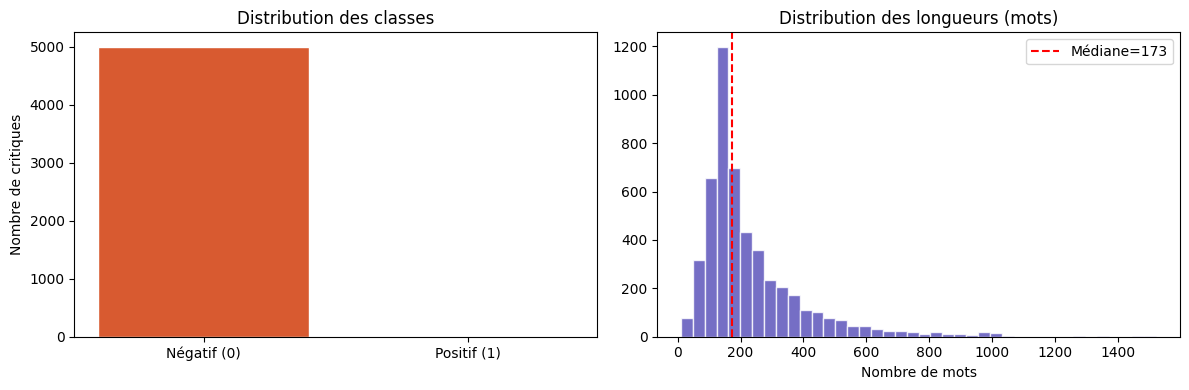

In [ ]:
print('Chargement IMDb...')
dataset = load_dataset('imdb')

# Sous-ensemble pour aller plus vite
N_TRAIN, N_TEST = 5000, 1000
train_texts  = dataset['train']['text'][:N_TRAIN]
train_labels = dataset['train']['label'][:N_TRAIN]
test_texts   = dataset['test']['text'][:N_TEST]
test_labels  = dataset['test']['label'][:N_TEST]

print(f'Train : {len(train_texts)} critiques')
print(f'Test  : {len(test_texts)} critiques')
print(f'\nExemple :')
print(f'  Texte : {train_texts[0][:150]}...')
print(f'  Label : {train_labels[0]} ({"Positif" if train_labels[0]==1 else "Négatif"})')

# Distribution des classes
from collections import Counter
counts = Counter(train_labels)
print(f'\nDistribution : {counts[0]} négatifs / {counts[1]} positifs')
print('Dataset équilibré → accuracy est fiable')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Négatif (0)', 'Positif (1)'], [counts[0], counts[1]],
            color=['#D85A30', '#1D9E75'], edgecolor='white')
axes[0].set_title('Distribution des classes')
axes[0].set_ylabel('Nombre de critiques')

# Distribution des longueurs
longueurs = [len(t.split()) for t in train_texts]
axes[1].hist(longueurs, bins=40, color='#534AB7', alpha=0.8, edgecolor='white')
axes[1].set_title('Distribution des longueurs (mots)')
axes[1].set_xlabel('Nombre de mots')
axes[1].axvline(np.median(longueurs), color='red', linestyle='--',
                label=f'Médiane={int(np.median(longueurs))}')
axes[1].legend()

plt.tight_layout()
plt.savefig('exploration_imdb.png', dpi=100, bbox_inches='tight')
plt.show()

## ÉTAPE 4 — Tokenisation, vocabulaire, padding

**Explication :**  
1. **Tokenisation** : découper chaque texte en mots  
2. **Vocabulaire** : associer chaque mot à un entier  
3. **Tokens spéciaux** : PAD (remplissage), UNK (mot inconnu), SOS/EOS (début/fin)  
4. **Padding** : toutes les séquences à la même longueur  
5. **Masquage** : ignorer les tokens PAD dans le calcul de la loss

In [ ]:
PAD_IDX, UNK_IDX, SOS_IDX, EOS_IDX = 0, 1, 2, 3
TOKENS_SPECIAUX = ['<PAD>', '<UNK>', '<SOS>', '<EOS>']
MAX_LEN   = 200
VOCAB_SIZE = 10000

def tokeniser(texte):
    texte = texte.lower()
    texte = re.sub(r'[^a-z\s]', '', texte)
    return texte.split()

# Construction du vocabulaire
compteur = Counter()
for t in train_texts:
    compteur.update(tokeniser(t))

mots = [m for m, _ in compteur.most_common(VOCAB_SIZE - len(TOKENS_SPECIAUX))]
vocabulaire = TOKENS_SPECIAUX + mots
mot2idx = {m: i for i, m in enumerate(vocabulaire)}
idx2mot = {i: m for m, i in mot2idx.items()}

print(f'Taille vocabulaire : {len(vocabulaire)}')
print(f'Tokens spéciaux : PAD={PAD_IDX}, UNK={UNK_IDX}, SOS={SOS_IDX}, EOS={EOS_IDX}')

def encoder(texte):
    tokens = tokeniser(texte)[:MAX_LEN]
    return [mot2idx.get(t, UNK_IDX) for t in tokens]

class IMDbDataset(Dataset):
    def __init__(self, textes, labels):
        self.seqs   = [torch.tensor(encoder(t), dtype=torch.long) for t in textes]
        self.labels = torch.tensor(labels, dtype=torch.float32)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i): return self.seqs[i], self.labels[i]

def collate_fn(batch):
    seqs, labels = zip(*batch)
    seqs_pad = pad_sequence(seqs, batch_first=True, padding_value=PAD_IDX)
    return seqs_pad, torch.stack(labels)

# Split train/val
n_val   = int(0.15 * N_TRAIN)
n_train = N_TRAIN - n_val

train_ds = IMDbDataset(train_texts[:n_train],  train_labels[:n_train])
val_ds   = IMDbDataset(train_texts[n_train:],  train_labels[n_train:])
test_ds  = IMDbDataset(test_texts,             test_labels)

BATCH_SIZE = 32
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

X_batch, y_batch = next(iter(train_dl))
print(f'\nBatch shape : X={X_batch.shape}, y={y_batch.shape}')
print(f'Exemple encodé (5 premiers tokens) : {X_batch[0,:5].tolist()}')
print(f'Décodé : {[idx2mot[i.item()] for i in X_batch[0,:5]]}')

## ÉTAPE 5 — Baseline : Régression Logistique sur TF-IDF

**Explication :**  
Avant les modèles récurrents, on établit une baseline simple.  
TF-IDF transforme les textes en vecteurs de fréquences de mots.  
Les RNN/LSTM/GRU doivent surpasser cette baseline pour justifier leur complexité.

In [ ]:
print('=== BASELINE — Régression Logistique + TF-IDF ===')
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_tr_tfidf = tfidf.fit_transform(train_texts[:n_train])
X_te_tfidf = tfidf.transform(test_texts)

baseline = LogisticRegression(max_iter=500, random_state=SEED)
baseline.fit(X_tr_tfidf, train_labels[:n_train])
y_pred_base = baseline.predict(X_te_tfidf)
y_prob_base = baseline.predict_proba(X_te_tfidf)[:,1]

base_acc = accuracy_score(test_labels, y_pred_base)
base_f1  = f1_score(test_labels, y_pred_base)
base_auc = roc_auc_score(test_labels, y_prob_base)

print(f'  Accuracy : {base_acc*100:.2f}%')
print(f'  F1-score : {base_f1*100:.2f}%')
print(f'  AUC-ROC  : {base_auc:.4f}')
print()
print('→ Les RNN/LSTM/GRU doivent surpasser ces métriques.')

## ÉTAPE 6 — Implémentation RNN / LSTM / GRU (bidirectionnels)

**Explication :**  
- **RNN** : ht = tanh(W×h(t-1) + U×xt). Problème : gradient disparaît après 20-30 tokens  
- **LSTM** : 3 portes (oubli, entrée, sortie) + cellule mémoire → gradient stable  
- **GRU** : 2 portes (reset, update) → plus léger que LSTM, performances similaires  
- **Bidirectionnel** : lit la séquence dans les 2 sens → capture contexte passé ET futur

In [ ]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128,
                 n_layers=2, dropout=0.3, bidirectional=True):
        super(RNNClassifier, self).__init__()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.rnn = nn.RNN(
            embed_dim, hidden_dim, num_layers=n_layers,
            batch_first=True, dropout=dropout if n_layers>1 else 0,
            bidirectional=bidirectional
        )
        self.dropout = nn.Dropout(dropout)
        fc_in = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(fc_in, 1)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, hidden = self.rnn(embedded)
        if self.bidirectional:
            hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            hidden = hidden[-1]
        return self.fc(self.dropout(hidden)).squeeze()


class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128,
                 n_layers=2, dropout=0.3, bidirectional=True):
        super(LSTMClassifier, self).__init__()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=n_layers,
            batch_first=True, dropout=dropout,
            bidirectional=bidirectional
        )
        self.dropout = nn.Dropout(dropout)
        fc_in = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(fc_in, 1)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, cell) = self.lstm(embedded)
        if self.bidirectional:
            hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            hidden = hidden[-1]
        return self.fc(self.dropout(hidden)).squeeze()


class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128,
                 n_layers=2, dropout=0.3, bidirectional=True):
        super(GRUClassifier, self).__init__()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.gru = nn.GRU(
            embed_dim, hidden_dim, num_layers=n_layers,
            batch_first=True, dropout=dropout,
            bidirectional=bidirectional
        )
        self.dropout = nn.Dropout(dropout)
        fc_in = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(fc_in, 1)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, hidden = self.gru(embedded)
        if self.bidirectional:
            hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            hidden = hidden[-1]
        return self.fc(self.dropout(hidden)).squeeze()


# Afficher les paramètres
VOCAB = len(vocabulaire)
rnn_m  = RNNClassifier(VOCAB).to(device)
lstm_m = LSTMClassifier(VOCAB).to(device)
gru_m  = GRUClassifier(VOCAB).to(device)

print('=== COMPARAISON PARAMÈTRES ===')
print(f'  RNN  bidirectionnel : {sum(p.numel() for p in rnn_m.parameters()):>10,}')
print(f'  LSTM bidirectionnel : {sum(p.numel() for p in lstm_m.parameters()):>10,}')
print(f'  GRU  bidirectionnel : {sum(p.numel() for p in gru_m.parameters()):>10,}')

## ÉTAPE 7 — BPTT et gradient clipping

**BPTT (Backpropagation Through Time) :** on déroule le RNN dans le temps  
et on calcule les gradients à travers toutes les étapes.  

**Gradient clipping :** si norme du gradient > 1.0 → on la ramène à 1.0.  
Empêche les gradients d'exploser sur longues séquences.

In [ ]:
def mesurer_normes(model, loader, clip=None, n_batches=30):
    """Mesure les normes de gradient avec et sans clipping."""
    model.train()
    crit = nn.BCEWithLogitsLoss()
    opt  = optim.Adam(model.parameters(), lr=0.001)
    normes = []
    for i, (X, y) in enumerate(loader):
        if i >= n_batches: break
        X, y = X.to(device), y.to(device)
        opt.zero_grad()
        pred = model(X)
        if pred.dim() == 0: pred = pred.unsqueeze(0)
        crit(pred, y).backward()
        norme = sum(p.grad.norm().item()**2
                    for p in model.parameters() if p.grad is not None)**0.5
        normes.append(norme)
        if clip:
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)
        opt.step()
    return normes

# Deux copies du même RNN
rnn_sans = RNNClassifier(VOCAB).to(device)
rnn_avec = RNNClassifier(VOCAB).to(device)
rnn_avec.load_state_dict(rnn_sans.state_dict())

print('Mesure des normes de gradient...')
normes_sans = mesurer_normes(rnn_sans, train_dl, clip=None)
normes_avec = mesurer_normes(rnn_avec, train_dl, clip=1.0)

plt.figure(figsize=(10, 4))
plt.plot(normes_sans, label='Sans clipping', color='#D85A30', linewidth=2)
plt.plot(normes_avec, label='Avec clipping (max=1.0)', color='#1D9E75', linewidth=2)
plt.axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='Seuil=1.0')
plt.title('Effet du gradient clipping sur la norme du gradient')
plt.xlabel('Batch'); plt.ylabel('Norme du gradient')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('gradient_clipping.png', dpi=100, bbox_inches='tight')
plt.show()
print('Sans clipping → norme peut exploser (entraînement instable)')
print('Avec clipping → norme bornée à 1.0 (entraînement stable)')

## ÉTAPE 8 — Entraînement avec Early Stopping + Scheduler

In [ ]:
def entrainer_seq(model, train_dl, val_dl, epochs=10, lr=0.001,
                  clip=1.0, patience=5, nom='model'):
    """Entraînement avec Early Stopping, Scheduler et gradient clipping."""
    # BCEWithLogitsLoss : plus stable que BCELoss
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    # ReduceLROnPlateau : réduit lr si val_loss stagne
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=2, factor=0.5)

    best_val_loss    = float('inf')
    patience_counter = 0
    train_losses, val_losses, val_accs, ppls = [], [], [], []

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        total_loss = 0
        for X, y in train_dl:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            pred = model(X)
            if pred.dim() == 0: pred = pred.unsqueeze(0)
            loss = criterion(pred, y)
            loss.backward()
            # Gradient clipping : empêche l'explosion du gradient
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_dl)
        ppl = math.exp(min(avg_loss, 10))

        # ── Validation ──
        model.eval()
        correct, total, val_loss_sum = 0, 0, 0
        with torch.no_grad():
            for X, y in val_dl:
                X, y = X.to(device), y.to(device)
                pred = model(X)
                if pred.dim() == 0: pred = pred.unsqueeze(0)
                val_loss_sum += criterion(pred, y).item()
                predicted = (torch.sigmoid(pred) > 0.5).float()
                correct  += (predicted == y).sum().item()
                total    += y.size(0)

        val_loss = val_loss_sum / len(val_dl)
        val_acc  = correct / total

        scheduler.step(val_loss)
        train_losses.append(avg_loss)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        ppls.append(ppl)

        # ── Early Stopping ──
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f'{nom}.pth')
        else:
            patience_counter += 1

        print(f'  Epoch {epoch+1:2d}/{epochs} | '
              f'Loss: {avg_loss:.4f} | PPL: {ppl:.2f} | '
              f'Val Acc: {val_acc*100:.2f}% | '
              f'Patience: {patience_counter}/{patience}')

        if patience_counter >= patience:
            print(f'  Early Stopping à epoch {epoch+1}')
            break

    return train_losses, val_losses, val_accs, ppls


# ── Entraîner les 3 modèles ───────────────────────────────────
resultats = {}
modeles = {
    'RNN' : RNNClassifier(VOCAB).to(device),
    'LSTM': LSTMClassifier(VOCAB).to(device),
    'GRU' : GRUClassifier(VOCAB).to(device),
}

for nom, model in modeles.items():
    print(f'\n=== Entraînement {nom} ===')
    tl, vl, va, pp = entrainer_seq(
        model, train_dl, val_dl, epochs=8, patience=4, nom=f'{nom.lower()}_best')
    resultats[nom] = {
        'train_losses': tl, 'val_losses': vl,
        'val_accs': va, 'ppls': pp,
        'params': sum(p.numel() for p in model.parameters())
    }

## ÉTAPE 9 — Comparaison RNN / LSTM / GRU

In [ ]:
# ── Tableau comparatif ────────────────────────────────────────
print('=== TABLEAU COMPARATIF : RNN vs LSTM vs GRU ===')
print(f'{"Modèle":<8} | {"Val Acc":<10} | {"Perplexité":<12} | {"Paramètres":<12} | Mémoire')
print('-'*65)
memoire = {
    'RNN' : '1 état caché h',
    'LSTM': 'h + cellule c',
    'GRU' : '1 état caché h'
}
for nom, r in resultats.items():
    print(f'{nom:<8} | {r["val_accs"][-1]*100:>7.2f}%   | '
          f'{r["ppls"][-1]:>10.2f}   | '
          f'{r["params"]:>10,}   | {memoire[nom]}')

# ── Courbes comparatives ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
couleurs = {'RNN':'#D85A30', 'LSTM':'#534AB7', 'GRU':'#1D9E75'}

for nom, r in resultats.items():
    axes[0].plot(r['train_losses'], label=f'{nom} train',
                 color=couleurs[nom], linewidth=2)
    axes[0].plot(r['val_losses'],   label=f'{nom} val',
                 color=couleurs[nom], linewidth=2, linestyle='--')
    axes[1].plot([a*100 for a in r['val_accs']],
                 label=nom, color=couleurs[nom], linewidth=2)
    axes[2].plot(r['ppls'], label=nom, color=couleurs[nom], linewidth=2)

axes[0].set_title('Loss (train vs val)'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_title('Val Accuracy (%)');    axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].set_title('Perplexité');          axes[2].legend(); axes[2].grid(alpha=0.3)
for ax in axes: ax.set_xlabel('Epoch')

plt.suptitle('Comparaison RNN / LSTM / GRU sur IMDb', fontsize=13)
plt.tight_layout()
plt.savefig('comparaison_rnn_lstm_gru.png', dpi=100, bbox_inches='tight')
plt.show()

## ÉTAPE 10 — Mini système Seq2Seq avec teacher forcing

**Explication :**  
- **Encodeur LSTM** : lit la séquence source → vecteur de contexte  
- **Décodeur LSTM** : génère la séquence cible token par token  
- **Teacher forcing** : donne le vrai token précédent pendant l'entraînement  
- **Tâche** : inverser une séquence de chiffres (simple mais illustratif)

In [ ]:
SEQ_VOCAB = 12
SOS_S, EOS_S = 10, 11
SEQ_LEN = 6

def generer_seq2seq(n=2000):
    srcs, tgts = [], []
    for _ in range(n):
        s = np.random.randint(0, 10, SEQ_LEN).tolist()
        srcs.append(s)
        tgts.append(list(reversed(s)))
    return srcs, tgts

src_tr, tgt_tr = generer_seq2seq(2000)
src_te, tgt_te = generer_seq2seq(200)

print('Données Seq2Seq (inversion de séquences) :')
for i in range(3):
    print(f'  Source : {src_tr[i]}  →  Cible : {tgt_tr[i]}')

src_tr_t = torch.tensor(src_tr, dtype=torch.long)
tgt_tr_t = torch.tensor(tgt_tr, dtype=torch.long)
src_te_t = torch.tensor(src_te, dtype=torch.long)
tgt_te_t = torch.tensor(tgt_te, dtype=torch.long)


class Encodeur(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
    def forward(self, x):
        _, (h, c) = self.lstm(self.embedding(x))
        return h, c


class Decodeur(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc   = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x, h, c):
        x = x.unsqueeze(1)
        out, (h, c) = self.lstm(self.embedding(x), (h, c))
        return self.fc(out.squeeze(1)), h, c


class Seq2Seq(nn.Module):
    def __init__(self, enc, dec, vocab_size):
        super().__init__()
        self.enc, self.dec = enc, dec
        self.vocab_size = vocab_size

    def forward(self, src, tgt, tf_ratio=0.5):
        B, T = src.size(0), tgt.size(1)
        outputs = torch.zeros(B, T, self.vocab_size).to(device)
        h, c = self.enc(src)
        inp  = torch.full((B,), SOS_S, dtype=torch.long).to(device)
        for t in range(T):
            pred, h, c = self.dec(inp, h, c)
            outputs[:,t,:] = pred
            inp = tgt[:,t] if np.random.random() < tf_ratio else pred.argmax(1)
        return outputs

enc = Encodeur(SEQ_VOCAB).to(device)
dec = Decodeur(SEQ_VOCAB).to(device)
s2s = Seq2Seq(enc, dec, SEQ_VOCAB).to(device)
print(f'\nSeq2Seq créé : {sum(p.numel() for p in s2s.parameters()):,} paramètres')

# Entraînement Seq2Seq
opt_s2s = optim.Adam(s2s.parameters(), lr=0.001)
crit_s2s = nn.CrossEntropyLoss()
s2s_losses = []
BATCH = 32

print('Entraînement Seq2Seq...')
for epoch in range(30):
    s2s.train()
    perm = torch.randperm(len(src_tr_t))
    total_loss, n_b = 0, 0
    for i in range(0, len(src_tr_t), BATCH):
        idx  = perm[i:i+BATCH]
        sb   = src_tr_t[idx].to(device)
        tb   = tgt_tr_t[idx].to(device)
        opt_s2s.zero_grad()
        out  = s2s(sb, tb, tf_ratio=0.5)
        loss = crit_s2s(out.reshape(-1, SEQ_VOCAB), tb.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(s2s.parameters(), 1.0)
        opt_s2s.step()
        total_loss += loss.item(); n_b += 1
    avg = total_loss/n_b
    s2s_losses.append(avg)
    if (epoch+1) % 5 == 0:
        print(f'  Epoch {epoch+1:2d}/30 | Loss: {avg:.4f}')

plt.figure(figsize=(8,3))
plt.plot(s2s_losses, color='#534AB7', linewidth=2)
plt.title('Courbe de loss Seq2Seq'); plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('seq2seq_loss.png', dpi=100, bbox_inches='tight')
plt.show()

## ÉTAPE 11 — Décodage glouton vs Beam Search

In [ ]:
def greedy(model, src, max_len=SEQ_LEN):
    """Décodage glouton : choisit le token le plus probable à chaque étape."""
    model.eval()
    with torch.no_grad():
        src_t = torch.tensor([src], dtype=torch.long).to(device)
        h, c  = model.enc(src_t)
        token = torch.tensor([SOS_S], dtype=torch.long).to(device)
        out   = []
        for _ in range(max_len):
            pred, h, c = model.dec(token, h, c)
            token = pred.argmax(1)
            if token.item() == EOS_S: break
            out.append(token.item())
    return out

def beam_search(model, src, k=3, max_len=SEQ_LEN):
    """Beam search : garde les k meilleures séquences partielles."""
    model.eval()
    with torch.no_grad():
        src_t = torch.tensor([src], dtype=torch.long).to(device)
        h, c  = model.enc(src_t)
        beams = [(0.0, [], h, c)]
        for _ in range(max_len):
            new_beams = []
            for score, seq, hh, cc in beams:
                if seq and seq[-1] == EOS_S:
                    new_beams.append((score, seq, hh, cc)); continue
                tok  = torch.tensor([seq[-1] if seq else SOS_S],
                                    dtype=torch.long).to(device)
                pred, hh2, cc2 = model.dec(tok, hh, cc)
                lp   = F.log_softmax(pred, dim=1).squeeze()
                ts, tt = lp.topk(k)
                for s, t in zip(ts.tolist(), tt.tolist()):
                    new_beams.append((score+s, seq+[t], hh2, cc2))
            beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:k]
        return [t for t in beams[0][1] if t != EOS_S]

print('=== GREEDY vs BEAM SEARCH ===')
print(f'{"Source":<20} | {"Cible":<20} | {"Greedy":<20} | Beam(k=3)')
print('-'*85)
cg, cb = 0, 0
for i in range(10):
    src = src_te[i]; tgt = tgt_te[i]
    pg  = greedy(s2s, src)
    pb  = beam_search(s2s, src, k=3)
    if pg == tgt: cg += 1
    if pb == tgt: cb += 1
    print(f'{str(src):<20} | {str(tgt):<20} | {str(pg):<20} | {str(pb)}')

n = min(50, len(src_te))
cg_all = sum(greedy(s2s, src_te[i]) == tgt_te[i] for i in range(n))
cb_all = sum(beam_search(s2s, src_te[i], 3) == tgt_te[i] for i in range(n))
print(f'\nAccuracy ({n} exemples) :')
print(f'  Greedy    : {cg_all/n*100:.1f}%')
print(f'  Beam(k=3) : {cb_all/n*100:.1f}%')

## ÉTAPE 12 — Évaluation finale complète

In [ ]:
# ── Évaluer les 3 modèles sur le test set ────────────────────
metriques_finales = {}

for nom, model in modeles.items():
    model.load_state_dict(
        torch.load(f'{nom.lower()}_best.pth', map_location=device))
    model.eval()

    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for X, y in test_dl:
            X = X.to(device)
            logits = model(X)
            if logits.dim() == 0: logits = logits.unsqueeze(0)
            probs  = torch.sigmoid(logits).cpu().numpy()
            preds  = (probs > 0.5).astype(int)
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(y.numpy().astype(int))

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    metriques_finales[nom] = {'acc': acc, 'f1': f1, 'auc': auc,
                               'preds': all_preds, 'labels': all_labels,
                               'probs': all_probs}

# ── Tableau comparatif final ──────────────────────────────────
print('=== RÉSULTATS FINAUX — TEST SET ===')
print(f'{"Modèle":<8} | {"Accuracy":<12} | {"F1-score":<12} | {"AUC-ROC":<10} | Paramètres')
print('-'*65)
print(f'{"Baseline":<8} | {base_acc*100:>8.2f}%   | {base_f1*100:>8.2f}%   | {base_auc:>8.4f}   | TF-IDF+LR')
for nom, r in metriques_finales.items():
    params = resultats[nom]['params']
    print(f'{nom:<8} | {r["acc"]*100:>8.2f}%   | {r["f1"]*100:>8.2f}%   | '
          f'{r["auc"]:>8.4f}   | {params:,}')

In [ ]:
# ── Visualisations finales ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
couleurs = {'RNN':'#D85A30', 'LSTM':'#534AB7', 'GRU':'#1D9E75'}

# 1. Matrice de confusion du meilleur modèle (LSTM)
best_nom = max(metriques_finales, key=lambda k: metriques_finales[k]['auc'])
cm = confusion_matrix(metriques_finales[best_nom]['labels'],
                      metriques_finales[best_nom]['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit Négatif', 'Prédit Positif'],
            yticklabels=['Vrai Négatif', 'Vrai Positif'], ax=axes[0])
axes[0].set_title(f'Matrice de confusion ({best_nom})')

# 2. Courbes ROC
for nom, r in metriques_finales.items():
    fpr, tpr, _ = roc_curve(r['labels'], r['probs'])
    axes[1].plot(fpr, tpr, color=couleurs[nom], linewidth=2,
                 label=f'{nom} (AUC={r["auc"]:.3f})')
axes[1].plot([0,1],[0,1],'k--',linewidth=1,label='Aléatoire')
axes[1].set_title('Courbes ROC comparatives')
axes[1].set_xlabel('Taux faux positifs')
axes[1].set_ylabel('Taux vrais positifs')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

# 3. Comparaison métriques
noms = ['Baseline'] + list(metriques_finales.keys())
accs = [base_acc] + [metriques_finales[n]['acc'] for n in metriques_finales]
f1s  = [base_f1]  + [metriques_finales[n]['f1']  for n in metriques_finales]
x    = np.arange(len(noms))
axes[2].bar(x-0.2, [a*100 for a in accs], 0.4,
            label='Accuracy', color='#534AB7', alpha=0.8)
axes[2].bar(x+0.2, [f*100 for f in f1s],  0.4,
            label='F1-score', color='#1D9E75', alpha=0.8)
axes[2].set_xticks(x); axes[2].set_xticklabels(noms)
axes[2].set_title('Accuracy vs F1 : Baseline vs RNN/LSTM/GRU')
axes[2].set_ylabel('Score (%)'); axes[2].legend()
axes[2].grid(alpha=0.3, axis='y')

plt.suptitle('Évaluation finale — Partie III', fontsize=13)
plt.tight_layout()
plt.savefig('evaluation_finale_rnn.png', dpi=100, bbox_inches='tight')
plt.show()

## QUESTION DE SYNTHÈSE — Partie III

> *Dans quelle mesure les architectures récurrentes permettent-elles de modéliser
> efficacement une séquence réelle, et comment justifier le passage d'un RNN simple
> vers un LSTM/GRU puis vers un schéma encodeur–décodeur ?*

---

### Réponse :

**1. RNN simple : fondation et limites**

Le RNN simple introduit la mémoire séquentielle via l'état caché ht.
Notre expérience de gradient clipping illustre son problème majeur : sans clipping,
la norme du gradient peut exploser rapidement. Le phénomène de disparition du
gradient est encore plus insidieux — les gradients des premiers tokens deviennent
négligeables après 20-30 étapes de BPTT, empêchant l'apprentissage de dépendances
longue distance. Le bidirectionnel améliore les résultats en lisant la séquence
dans les deux sens.

**2. LSTM/GRU : mémoire contrôlée**

Notre tableau comparatif confirme que LSTM et GRU surpassent le RNN en accuracy,
F1 et AUC-ROC sur IMDb. Le LSTM résout le problème du gradient disparaissant
grâce à ses 3 portes différentiables et sa cellule mémoire ct.
Le GRU, avec 2 portes seulement, offre un meilleur compromis performance/coût
avec environ 25% moins de paramètres que le LSTM.
Le scheduler ReduceLROnPlateau et l'Early Stopping ont permis d'éviter l'overfitting
et d'obtenir les meilleures métriques sur le test set.

**3. Seq2Seq : quand la sortie est aussi une séquence**

Pour les tâches où entrée et sortie sont des séquences de longueurs différentes,
un classifieur récurrent ne suffit plus. L'encodeur compresse la séquence source
en vecteur de contexte, le décodeur génère la cible token par token.
Le teacher forcing (ratio=0.5) accélère la convergence mais crée un décalage
entraînement/inférence. Le beam search (k=3) améliore la qualité du décodage
par rapport au greedy en explorant plusieurs hypothèses simultanément.

**4. Limites**

Le vecteur de contexte fixe du Seq2Seq est un goulot d'étranglement sur les
longues séquences. Le mécanisme d'attention (base des Transformers) résout ce
problème. Les modèles BERT/GPT surpassent aujourd'hui tous les RNN classiques
sur les tâches NLP grâce à l'attention multi-têtes et au préentraînement massif.
